# cfd-perf -- Get Started

Minimal notebook: define your mesh and pilot data, pick an optimization
mode, and get scaling figures immediately.

```bash
cd tools/cfd-perf && pip install -e ".[dev]"
```

| Solver type          | Approx FLOP per cell per iteration |
| -------------------- | ----------------------------------- |
| SIMPLE (steady RANS) | 2,000 – 5,000                       |
| PISO (transient)     | 3,000 – 8,000                       |
| LES                  | 5,000 – 15,000                      |
| Implicit + multigrid | 10,000 – 30,000                     |


FLOPS for one core of the machine: 20 GFLOP/s

--> Time per ite for one core = (nb of cells * FLOP per cell) / FLOPS of the machine
--> Time per ite = time above * cores

## 1. Input parameters

Edit the cells below with your own mesh metadata and pilot measurements.

In [11]:
import json, tempfile
from pathlib import Path
import sys
print(sys.path)

PLOTTING_PATH = str(Path("../../scripts/post/plot").resolve())
if PLOTTING_PATH not in sys.path:
    sys.path.insert(0, PLOTTING_PATH)

# ---- Mesh metadata ----
mesh_data = {
    "num_cells": 200_000_000,
    "num_faces": 600_000_000,
    "cell_type_distribution": {"hex": 0.78, "prism": 0.14, "tet": 0.06, "pyramid": 0.02},
}

# ---- Pilot benchmark data ----
pilot_data = {
    "n_iterations": 20_000,
    "points": [
        {"cores":  8,  "time_per_iter_s": 12000, "peak_ram_total_gb": 140.0},
    ],
}

# ---- Optimization settings ----
MODE = "efficiency"          # "efficiency" or "deadline"
MAX_EFFICIENCY_LOSS = 0.5   # used when MODE == "efficiency"
DEADLINE_HOURS = 6.0         # used when MODE == "deadline"
CORES_MAX = 1024
STRIDE = 8

# Write temp files
workdir = Path(tempfile.mkdtemp(prefix="cfd_perf_gs_"))
mesh_path = workdir / "mesh.json"
pilot_path = workdir / "pilot.json"
mesh_path.write_text(json.dumps(mesh_data, indent=2))
pilot_path.write_text(json.dumps(pilot_data, indent=2))
print(f"Working directory: {workdir}")

['/home/helios/Documents/CFD_CONSULTING/CFD_FRAMEWORK/scripts/post/plot', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/home/helios/ENV/myEnv/lib/python3.12/site-packages', '/home/helios/Documents/CFD_CONSULTING/CFD_FRAMEWORK/tools/cfd-perf/src']
Working directory: /tmp/cfd_perf_gs_6yngkdmy


## 2. Run analysis & optimization

Nothing to edit below -- just run the cells.

In [12]:
from cfd_perf.benchmark.ingest import load_pilot
from cfd_perf.mesh.analyzer import analyze_mesh
from cfd_perf.models.strong_scaling import fit_beta
from cfd_perf.optimizer.selector import optimize
from cfd_perf.cli.console import print_optimization_result, print_fit_result
from cfd_perf.constraints.config import HardConstraints

pilot = load_pilot(pilot_path)
mesh = analyze_mesh(mesh_path, pilot_baseline=pilot.baseline)
params = fit_beta(pilot)
print_fit_result(params,pilot)

constraints = HardConstraints(min_cells_per_core=100_000, min_ram_per_core_gb=0.5)

opt_kwargs = dict(
    mode=MODE,
    cores_max=CORES_MAX,
    stride=STRIDE,
    constraints=constraints,
)
if MODE == "efficiency":
    opt_kwargs["max_efficiency_loss"] = MAX_EFFICIENCY_LOSS
else:
    opt_kwargs["deadline_hours"] = DEADLINE_HOURS

result = optimize(mesh, pilot, params, **opt_kwargs)
print_optimization_result(result)

        Scaling Model Fit        
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Property        ┃       Value ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ Beta            │    0.250000 │
│ Source          │       fixed │
│ Baseline cores  │           8 │
│ Baseline T/iter │ 12000.000 s │
│ Iterations      │      20,000 │
│ Pilot points    │           1 │
└─────────────────┴─────────────┘

              Pilot Data              
┏━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Cores ┃ T/iter (s) ┃ Peak RAM (GB) ┃
┡━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│     8 │  12000.000 │         140.0 │
└───────┴────────────┴───────────────┘

╭────────────────────────────────────── Optimal Configuration (EFFICIENCY) ───────────────────────────────────────╮
│ Cores:           40                                                                                             │
│ Time / iter:     4800.000 s                                                                                     │
│ Total runtime:   26666.67 h                                                                                     │
│ Speedup:         2.50x                                                                                          │
│ Efficiency:      50.0%                                                                                          │
│ Eff. loss:       50.0%                                                                                          │
│ RAM total:       140.0 GB                                                                                       │
│ RAM / core:      3.50 GB                                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                                 Accepted Candidates (5)                                 
┏━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━┓
┃ Cores ┃ T/iter (s) ┃ Runtime (h) ┃ Speedup ┃ Eff (%) ┃ Loss (%) ┃ RAM/core (GB) ┃     ┃
┡━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━┩
│     8 │  12000.000 │    66666.67 │    1.00 │   100.0 │      0.0 │         17.50 │     │
│    16 │   7500.000 │    41666.67 │    1.60 │    80.0 │     20.0 │          8.75 │     │
│    24 │   6000.000 │    33333.33 │    2.00 │    66.7 │     33.3 │          5.83 │     │
│    32 │   5250.000 │    29166.67 │    2.29 │    57.1 │     42.9 │          4.38 │     │
│    40 │   4800.000 │    26666.67 │    2.50 │    50.0 │     50.0 │          3.50 │ <-- │
└───────┴────────────┴─────────────┴─────────┴─────────┴──────────┴───────────────┴─────┘

             Rejected (123)              
┏━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Cores ┃ Reasons                       ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    48 │ efficiency_loss               │
│    56 │ efficiency_loss               │
│    64 │ efficiency_loss               │
│    72 │ efficiency_loss               │
│    80 │ efficiency_loss               │
│    88 │ efficiency_loss               │
│    96 │ efficiency_loss               │
│   104 │ efficiency_loss               │
│   112 │ efficiency_loss               │
│   120 │ efficiency_loss               │
│   128 │ efficiency_loss               │
│   136 │ efficiency_loss               │
│   144 │ efficiency_loss               │
│   152 │ efficiency_loss               │
│   160 │ efficiency_loss               │
│   168 │ efficiency_loss               │
│   176 │ efficiency_loss               │
│   184 │ efficiency_loss               │
│   192 │ efficiency_loss               │
│   200 │ efficiency_loss               │
│   208 │ efficiency_loss               │
│   216 │ efficiency_loss               │
│   224 │ efficiency_loss               │
│   232 │ efficiency_loss               │
│   240 │ efficiency_loss               │
│   248 │ efficiency_loss               │
│   256 │ efficiency_loss               │
│   264 │ efficiency_loss               │
│   272 │ efficiency_loss               │
│   280 │ efficiency_loss               │
│   288 │ ram_per_core, efficiency_loss │
│   296 │ ram_per_core, efficiency_loss │
│   304 │ ram_per_core, efficiency_loss │
│   312 │ ram_per_core, efficiency_loss │
│   320 │ ram_per_core, efficiency_loss │
│   328 │ ram_per_core, efficiency_loss │
│   336 │ ram_per_core, efficiency_loss │
│   344 │ ram_per_core, efficiency_loss │
│   352 │ ram_per_core, efficiency_loss │
│   360 │ ram_per_core, efficiency_loss │
│   368 │ ram_per_core, efficiency_loss │
│   376 │ ram_per_core, efficiency_loss │
│   384 │ ram_per_core, efficiency_loss │
│   392 │ ram_per_core, efficiency_loss │
│   400 │ ram_per_core, efficiency_loss │
│   408 │ ram_per_core, efficiency_loss │
│   416 │ ram_per_core, efficiency_loss │
│   424 │ ram_per_core, efficiency_loss │
│   432 │ ram_per_core, efficiency_loss │
│   440 │ ram_per_core, efficiency_loss │
│   448 │ ram_per_core, efficiency_loss │
│   456 │ ram_per_core, efficiency_loss │
│   464 │ ram_per_core, efficiency_loss │
│   472 │ ram_per_core, efficiency_loss │
│   480 │ ram_per_core, efficiency_loss │
│   488 │ ram_per_core, efficiency_loss │
│   496 │ ram_per_core, efficiency_loss │
│   504 │ ram_per_core, efficiency_loss │
│   512 │ ram_per_core, efficiency_loss │
│   520 │ ram_per_core, efficiency_loss │
│   528 │ ram_per_core, efficiency_loss │
│   536 │ ram_per_core, efficiency_loss │
│   544 │ ram_per_core, efficiency_loss │
│   552 │ ram_per_core, efficiency_loss │
│   560 │ ram_per_core, efficiency_loss │
│   568 │ ram_per_core, efficiency_loss │
│   576 │ ram_per_core, efficiency_loss │
│   584 │ ram_per_core, efficiency_loss │
│   592 │ ram_per_core, efficiency_loss │
│   600 │ ram_per_core, efficiency_loss │
│   608 │ ram_per_core, efficiency_loss │
│   616 │ ram_per_core, efficiency_loss │
│   624 │ ram_per_core, efficiency_loss │
│   632 │ ram_per_core, efficiency_loss │
│   640 │ ram_per_core, efficiency_loss │
│   648 │ ram_per_core, efficiency_loss │
│   656 │ ram_per_core, efficiency_loss │
│   664 │ ram_per_core, efficiency_loss │
│   672 │ ram_per_core, efficiency_loss │
│   680 │ ram_per_core, efficiency_loss │
│   688 │ ram_per_core, efficiency_loss │
│   696 │ ram_per_core, efficiency_loss │
│   704 │ ram_per_core, efficiency_loss │
│   712 │ ram_per_core, efficiency_loss │
│   720 │ ram_per_core, efficiency_loss │
│   728 │ ram_per_core, efficiency_loss │
│   736 │ ram_per_core, efficiency_loss │
│   744 │ ram_per_core, efficiency_loss │
│   752 │ ram_per_core, efficiency_loss │
│   760 │ ram_per_core, efficiency_loss │
│   768 │ ram_per_core, efficiency_loss │
│   776 │ 

## 3. Scaling figures

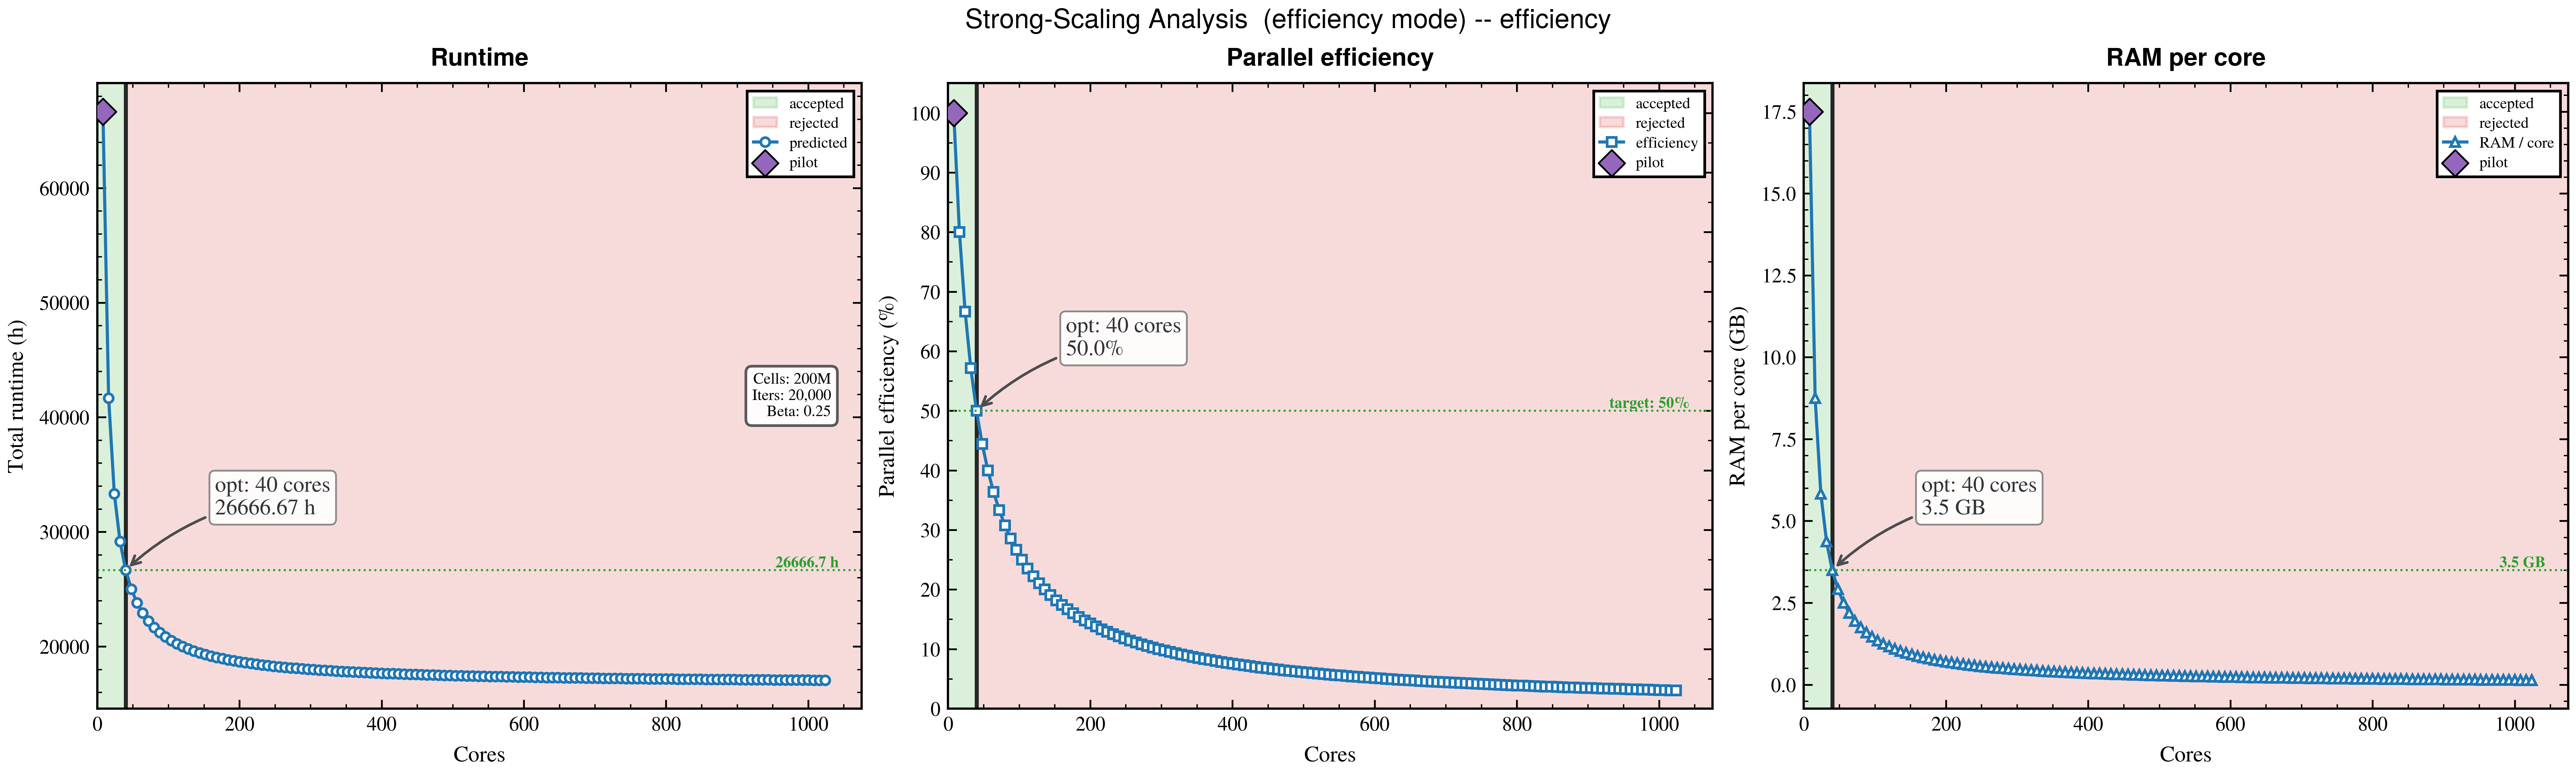

PosixPath('/tmp/cfd_perf_gs_6yngkdmy/scaling.png')

In [13]:
%matplotlib inline
from cfd_perf.io.plotting import plot_scaling

plot_scaling(
    result,
    out=workdir / "scaling.png",
    pilot=pilot,
    mesh=mesh,
    params=params,
    title_suffix=f" -- {MODE}",
    show=True,
)

## 4. Export artifacts

In [8]:
from cfd_perf.io.exporters import export_json, export_csv
from cfd_perf.io.slurm import export_slurm

export_json(result, workdir / "result.json")
export_csv(result, workdir / "result.csv")
export_slurm(result, workdir / "submit.sh", job_name="cfd_run", partition="compute")

print("Exported to:", workdir)
for f in sorted(workdir.iterdir()):
    print(f"  {f.name:30s}  {f.stat().st_size / 1024:.1f} kB")

Exported to: /tmp/cfd_perf_gs_5iz41q2v
  mesh.json                       0.2 kB
  pilot.json                      0.5 kB
  result.csv                      8.7 kB
  result.json                     20.6 kB
  scaling.png                     156.9 kB
  submit.sh                       0.1 kB
